# Fase 0 — Conclusões

Consolidação das três partes da fase de entendimento. Cada afirmação foi demonstrada num dos notebooks anteriores, indicado entre colchetes.

| notebook | pergunta que respondeu |
|---|---|
| [01 — Os dados](01_fase0a_osDados.ipynb) | O que são os dados e o que move a demanda? |
| [02 — O custo do problema](02_fase0b_oCustoDoProblema.ipynb) | Quanto custa o problema, e o que dizem os indicadores de estoque? |
| [03 — O ciclo de reposição](03_fase0c_cicloDeReposicao.ipynb) | Por que acontece, quanto estoque deveria haver e o que prever? |

## A história em um parágrafo

Uma rede de varejo com 5 lojas e 20 produtos deixa de atender **6% da sua demanda** por falta de produto, o que representa **R\$ 13,3 milhões por ano** em vendas que nunca aconteceram e não aparecem em nenhum relatório de faturamento. A causa não é o fornecedor nem a falta de dinheiro — a rede gasta apenas R\$ 0,3 a 0,5 milhão por ano carregando estoque —, mas o **dimensionamento**: os itens de maior giro são repostos em cima da hora, sem margem, e qualquer dia acima da média vira ruptura. Corrigir custa **+12,5% de capital** e depende de uma capacidade que a rede não tem: prever a demanda alta de cada item, não a média.

## Os números que sustentam a conclusão

A célula abaixo recalcula, a partir do arquivo bruto, todos os indicadores citados, para que a síntese seja verificável e não dependa de valores transcritos à mão.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd

ANOS = 760 / 365
CUSTO_CARREGAMENTO = 0.25
NIVEL_SERVICO = 0.95

caminho = next(arq for pasta in [Path("."), Path("projeto"), Path("..")]
               for arq in sorted(pasta.glob("sales_data*.csv")))
nomes = {"Date": "data", "Store ID": "loja", "Product ID": "produto", "Category": "categoria",
         "Region": "regiao", "Inventory Level": "estoque", "Units Sold": "vendas",
         "Units Ordered": "pedidos", "Price": "preco", "Discount": "desconto",
         "Weather Condition": "clima", "Promotion": "promocao",
         "Competitor Pricing": "preco_concorrente", "Seasonality": "estacao",
         "Epidemic": "epidemia", "Demand": "demanda"}
v = (pd.read_csv(caminho, parse_dates=["Date"]).rename(columns=nomes)
     .assign(sku=lambda d: d["loja"] + "-" + d["produto"])
     .sort_values(["sku", "data"]).reset_index(drop=True))
v["preco"] = v.groupby("sku")["preco"].transform("median")  # preço estável por SKU (mediana)

v["ruptura"] = v["demanda"] > v["estoque"]
v["perdida_un"] = (v["demanda"] - v["estoque"]).where(v["ruptura"], 0)
v["receita"] = v["vendas"] * v["preco"]
v["receita_perdida"] = v["perdida_un"] * v["preco"]
v["valor_estoque"] = v["estoque"] * v["preco"]

receita_ano = v["receita"].sum() / ANOS
perda_ano = v["receita_perdida"].sum() / ANOS
capital = v.groupby("data")["valor_estoque"].sum().mean()

kpis = [
    ("ESTRUTURA (0a)", "", ""),
    ("SKUs (loja × produto)", f"{v['sku'].nunique()}", "unidade de observação real"),
    ("dias por SKU", f"{v.groupby('sku').size().iloc[0]}", "painel, não amostra"),
    ("nível de serviço (fill rate)", f"{v['vendas'].sum() / v['demanda'].sum():.1%}", "demanda que vira venda"),
    ("CUSTO (0b)", "", ""),
    ("dias-SKU em ruptura", f"{v['ruptura'].mean():.1%}", "demanda > estoque"),
    ("demanda não atendida", f"{v['perdida_un'].sum() / v['demanda'].sum():.1%}", "fração perdida"),
    ("receita perdida / ano", f"R$ {perda_ano/1e6:,.1f} M", f"{perda_ano/receita_ano:.1%} da receita"),
    ("capital imobilizado", f"R$ {capital/1e6:,.2f} M", f"{v['estoque'].mean()/v['demanda'].mean():.1f} dias de cobertura"),
    ("custo de carregamento / ano", f"R$ {capital*CUSTO_CARREGAMENTO/1e3:,.0f} mil", "a 25% a.a."),
    ("razão perda / carregamento", f"{perda_ano / (capital*CUSTO_CARREGAMENTO):.0f} : 1", "ordem de grandeza"),
    ("CICLO E ALVO (0c)", "", ""),
    ("demanda média diária", f"{v['demanda'].mean():.1f} un.", "o que NÃO prever"),
    ("quantil 95 da demanda", f"{v['demanda'].quantile(NIVEL_SERVICO):.0f} un.", "o que o modelo deve prever"),
    ("custo de 1 un. a menos", f"R$ {v['receita_perdida'].sum()/v['perdida_un'].sum():.2f}", "venda perdida"),
    ("custo de 1 un. a mais", f"R$ {v['preco'].mean()*CUSTO_CARREGAMENTO:.2f}", "carregamento / ano"),
]
print(pd.DataFrame(kpis, columns=["indicador", "valor", "observação"])
      .to_markdown(index=False, tablefmt="grid"))

+------------------------------+------------+----------------------------+
| indicador                    | valor      | observação                 |
+==============================+============+============================+
| ESTRUTURA (0a)               |            |                            |
+------------------------------+------------+----------------------------+
| SKUs (loja × produto)        | 100        | unidade de observação real |
+------------------------------+------------+----------------------------+
| dias por SKU                 | 760        | painel, não amostra        |
+------------------------------+------------+----------------------------+
| nível de serviço (fill rate) | 85.2%      | demanda que vira venda     |
+------------------------------+------------+----------------------------+
| CUSTO (0b)                   |            |                            |
+------------------------------+------------+----------------------------+
| dias-SKU em ruptura    

## O fio condutor, em um quadro

As três fases encadeiam uma única linha de raciocínio: do que os dados **são** até o que o modelo **precisa fazer**.

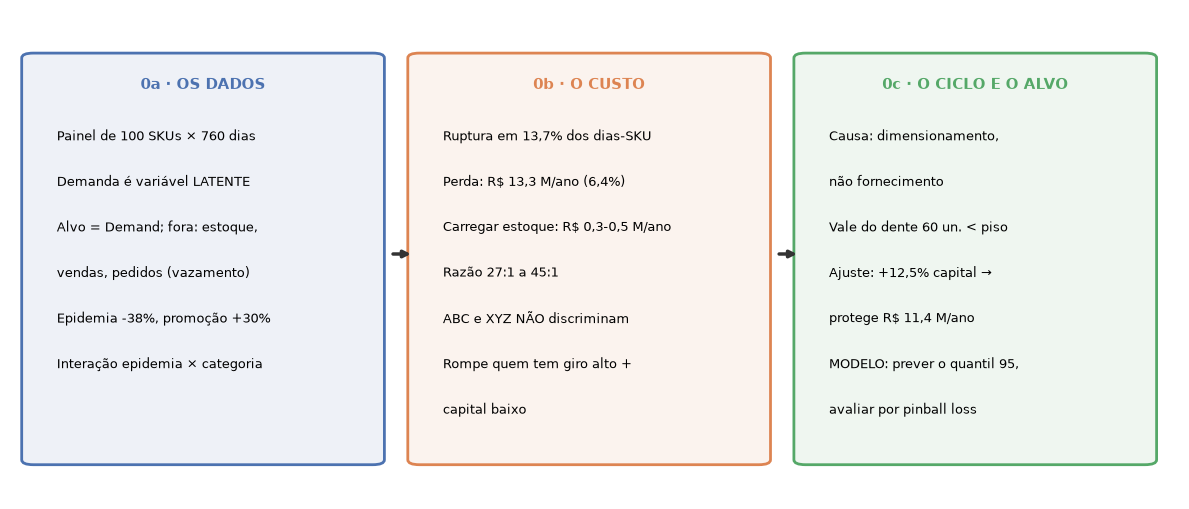

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 5.2))
ax.axis("off")

blocos = [
    (0.02, "0a · OS DADOS", "#4C72B0",
     ["Painel de 100 SKUs × 760 dias", "Demanda é variável LATENTE",
      "Alvo = Demand; fora: estoque,", "vendas, pedidos (vazamento)",
      "Epidemia -38%, promoção +30%", "Interação epidemia × categoria"]),
    (0.35, "0b · O CUSTO", "#DD8452",
     ["Ruptura em 13,7% dos dias-SKU", "Perda: R$ 13,3 M/ano (6,4%)",
      "Carregar estoque: R$ 0,3-0,5 M/ano", "Razão 27:1 a 45:1",
      "ABC e XYZ NÃO discriminam", "Rompe quem tem giro alto +", "capital baixo"]),
    (0.68, "0c · O CICLO E O ALVO", "#55A868",
     ["Causa: dimensionamento,", "não fornecimento", "Vale do dente 60 un. < piso",
      "Ajuste: +12,5% capital →", "protege R$ 11,4 M/ano",
      "MODELO: prever o quantil 95,", "avaliar por pinball loss"]),
]
for x, titulo, cor, linhas in blocos:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, 0.08), 0.29, 0.82, boxstyle="round,pad=0.01",
        linewidth=2, edgecolor=cor, facecolor=cor + "18"))
    ax.text(x + 0.145, 0.845, titulo, ha="center", va="center",
            fontsize=11, weight="bold", color=cor)
    for k, linha in enumerate(linhas):
        ax.text(x + 0.02, 0.74 - k * 0.093, linha, ha="left", va="center", fontsize=9.5)

for x in [0.325, 0.655]:
    ax.annotate("", xy=(x + 0.02, 0.5), xytext=(x, 0.5),
                arrowprops=dict(arrowstyle="-|>", lw=2.5, color="#333333"))

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

**Como ler.** Os três blocos são as três partes da fase 0, e as setas indicam que cada um responde a uma pergunta aberta pelo anterior: o que os dados **são** → quanto o problema **custa** → **por que** acontece e o que prever.

## Conclusões, por tema

### 1. O dataset é sintético, e isso condiciona tudo `[01]`

O conjunto ([Kaggle, Wavelet/`atomicd`, Apache 2.0](https://www.kaggle.com/datasets/atomicd/retail-store-inventory-and-demand-forecasting)) foi gerado por simulação. Quatro relações plantadas pelo gerador se confundem com descobertas: ausência total de falhas; ruído de ±10 unidades entre venda e demanda, mas só onde o estoque não limitou; impossibilidade de neve fora do inverno e do outono; preço do concorrente derivado do próprio preço (0,977).

Qualquer resultado precisa ser lido com a pergunta "isto é da operação ou do gerador?".

### 2. A unidade de observação é o SKU `[01]`

Não são 76.000 observações independentes, e sim um painel de 100 séries de 760 dias. Nenhum dos 20 códigos de produto mantém a mesma categoria nas cinco lojas, então só o par `loja + produto` tem significado. As variáveis são medidas em níveis diferentes (dia, dia × região, SKU × dia), o que define a base de contagem de cada uma. `regiao` duplica `loja`; `estacao` recodifica o mês.

### 3. A demanda é latente, mas continua sendo o alvo `[01]`

Em operação real a demanda não é registrada, só a venda. Substituí-la pelas vendas introduziria viés de −24% a −9% conforme o SKU e realimentaria o próprio problema — a *espiral descendente da demanda*. O que preserva o realismo é a exclusão de `estoque`, `vendas` e `pedidos` dos preditores, por só existirem depois do dia encerrado.

### 4. O que move a demanda `[01]`

Em ordem de magnitude: epidemia (−38%), categoria (+64%), promoção (+30%), clima (+23%), estação (+16%).

A epidemia **não** atinge as categorias igualmente (−69% em brinquedos, +1% em roupas): é uma interação, e um modelo aditivo erra nos extremos. E o preço tem correlação nula com a demanda (−0,02), anomalia deixada em aberto.

### 5. O problema custa R\$ 13 milhões por ano `[02]`

A rede rompe em **13,7% dos dias-SKU**, em episódios curtos (79% de um único dia). São **6% da demanda** não atendida — R\$ 13,3 M/ano, ou 6,4% da receita, invisíveis em qualquer relatório de vendas. A perda não se distribui como a receita: roupas perdem proporcionalmente o dobro de móveis.

### 6. Comprar estoque não é a solução óbvia `[02]`

O contrapeso é o capital imobilizado: R\$ 1,98 M em média, a um custo de R\$ 0,3–0,5 M/ano. A operação é enxuta (2,89 dias de cobertura), e as segmentações clássicas não ajudam neste sortimento — a curva ABC é anormalmente plana (58 SKUs para 80% da receita) e 93 dos 100 SKUs seriam classe X no XYZ. O que separa quem rompe é **giro alto com capital baixo**, não porte nem variabilidade.

### 7. A causa é dimensionamento, não fornecimento `[03]`

Reconstruídas as 28.831 entregas pela equação de balanço, elas casam com pedidos de quantidade idêntica e o prazo é constante por SKU (95 de 100). Contraintuitivamente, os SKUs que mais rompem **recebem o melhor serviço** — prazo zero, entrega quase diária. O problema está no estoque-alvo.

O dente de serra torna isso preciso: a ruptura acontece no **vale** do ciclo, não na média, e nos SKUs críticos o vale mergulha 60 unidades abaixo do necessário. Comparar o alvo com o estoque médio — o erro natural — inverteria a conclusão, indicando capital sobrando onde falta.

### 8. A correção compensa com folga `[03]`

Levar os 75 SKUs sub-dimensionados ao alvo custa **+12,5% de capital** (R\$ 37–62 mil/ano de carregamento) e protege **R\$ 11,4 M/ano** de receita em risco. A margem bruta de equilíbrio é de 0,3% a 0,5%, superada por qualquer operação de varejo. Como capital parado e receita perdida não se correlacionam entre SKUs, parte do aumento pode vir de realocação, não de compra nova.

## O que a fase 0 entrega para a modelagem

A fase de entendimento não descreveu apenas os dados: ela **especificou o modelo**.

| # | decisão | origem |
|---|---|---|
| 1 | prever o **quantil 95** da demanda diária, não a média (104 contra 188 un.) | `[03]` |
| 2 | **regressão quantílica / pinball loss** em vez de OLS+RMSE — o erro é assimétrico (~3:1) | `[03]` |
| 3 | **preditores restritos** ao disponível antes do dia | `[01]` |
| 4 | **codificar a interação** epidemia × categoria — modelo aditivo erra nos extremos | `[01]` |
| 5 | investigar o **mistério do preço** pelo preço relativo dentro do SKU | `[01]` |

> **O modelo não precisa acertar quanto se vende em média; precisa acertar quanto se venderia num dia movimentado.** É essa a informação que dimensiona o estoque e elimina a ruptura.

A fase 1 começa pela [Trilha A](05_fase1a_regressaoLinear.ipynb), que testa a decisão 5 e verifica, uma a uma, as suposições por trás das decisões 1 a 4.